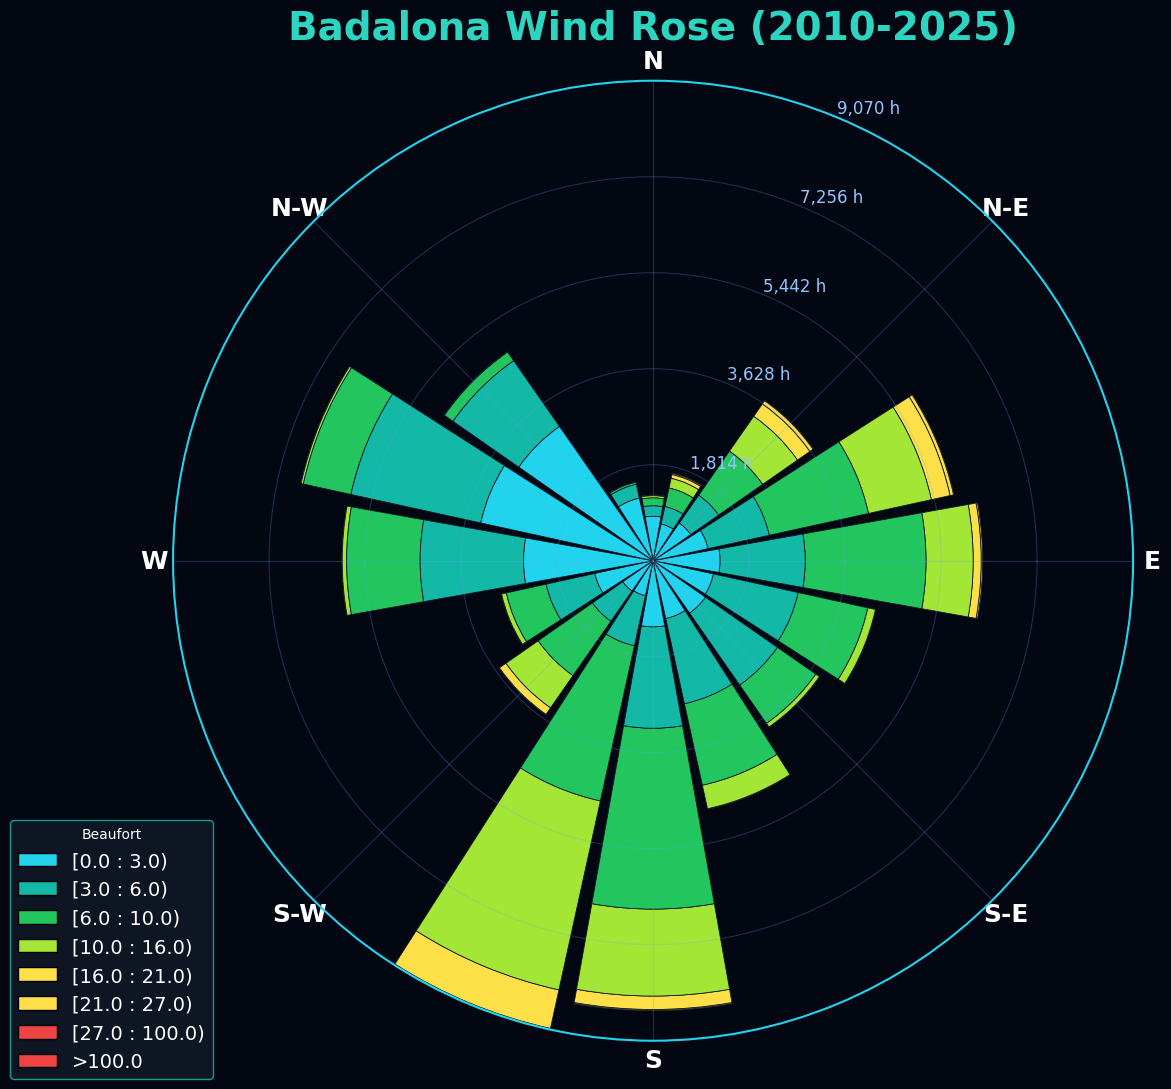

In [13]:
# ==========================================================
# BADALONA WIND ROSE
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from windrose import WindroseAxes

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------

df = pd.read_parquet(
    "../data/processed/bdlona_logs.parquet"
)


# ----------------------------------------------------------
# CLEAN DATA
# ----------------------------------------------------------

df = df[
    (df["wind_direction_deg"] >= 0)
    &
    (df["wind_direction_deg"] <= 360)
    &
    (df["wind_avg"] >= 0)
].copy()

# ----------------------------------------------------------
# BEAUFORT BINS (KNOTS)
# ----------------------------------------------------------

beaufort_bins = [
    0,
    3,
    6,
    10,
    16,
    21,
    27,
    100
]

# ----------------------------------------------------------
# COLOR PALETTE
# Dashboard style:
# cyan -> green -> yellow -> orange -> red
# ----------------------------------------------------------

colors = [
    "#22D3EE",   # cyan
    "#14B8A6",   # teal
    "#22C55E",   # green
    "#A3E635",   # lime
    "#FDE047",   # yellow
    "#F59E0B",   # orange
    "#EF4444"    # red
]

cmap = ListedColormap(colors)

# ----------------------------------------------------------
# FIGURE
# ----------------------------------------------------------

fig = plt.figure(
    figsize=(14, 12),
    facecolor="#030712"
)

ax = WindroseAxes.from_ax(
    fig=fig
)

# ----------------------------------------------------------
# BACKGROUND
# ----------------------------------------------------------

ax.set_facecolor("#030712")

# ----------------------------------------------------------
# WIND ROSE
# ----------------------------------------------------------

ax.bar(
    df["wind_direction_deg"],
    df["wind_avg"],
    bins=beaufort_bins,
    cmap=cmap,
    opening=0.90,
    edgecolor="#111827",
    linewidth=0.6,
    normed=True
)

# ----------------------------------------------------------
# TITLE
# ----------------------------------------------------------

plt.title(
    "Badalona Wind Rose (2010-2025)",
    fontsize=28,
    color="#2DD4BF",
    pad=30,
    weight="bold"
)

# ----------------------------------------------------------
# GRID STYLE
# ----------------------------------------------------------

ax.grid(
    color="#60A5FA",
    alpha=0.25,
    linewidth=0.8
)

# ----------------------------------------------------------
# POLAR LABELS
# ----------------------------------------------------------

for label in ax.get_xticklabels():
    label.set_color("white")
    label.set_fontsize(18)
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_color("#93C5FD")
    label.set_fontsize(12)

# ----------------------------------------------------------
# LEGEND
# ----------------------------------------------------------

legend = ax.legend(
    title="Beaufort",
    loc="lower left",
    bbox_to_anchor=(-0.18, -0.05),
    fontsize=14
)

legend.get_title().set_color("white")

for text in legend.get_texts():
    text.set_color("white")

legend.get_frame().set_facecolor("#111827")
legend.get_frame().set_edgecolor("#14B8A6")
legend.get_frame().set_alpha(0.85)

# ----------------------------------------------------------
# OUTER CIRCLE COLOR
# ----------------------------------------------------------

ax.spines["polar"].set_color("#22D3EE")
ax.spines["polar"].set_linewidth(1.5)

# ----------------------------------------------------------
# OPTIONAL HOURS SCALE
# (each sample = 15 minutes = 0.25 h)
# ----------------------------------------------------------

total_hours = len(df) * 0.25

ticks = ax.get_yticks()

hours = (
    ticks
    * total_hours
    / 100
)

ax.set_yticklabels(
    [f"{int(h):,} h" for h in hours]
)

# ----------------------------------------------------------
# SAVE IMAGE
# ----------------------------------------------------------

plt.savefig(
    "badalona_wind_rose_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#030712"
)

plt.show()

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from windrose import WindroseAxes

from matplotlib.colors import ListedColormap

In [3]:
df = pd.read_parquet(
    "../data/processed/bdlona_logs.parquet"
)

print(df.shape)

df.head()

(298674, 9)


,datetime,spot,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,source_file
0,2010-01-01 08:00:07,BDLONA,10,267,11,4,19,1,100101.log
1,2010-01-01 08:15:09,BDLONA,11,279,9,3,18,1,100101.log
2,2010-01-01 08:30:01,BDLONA,11,270,10,4,17,1,100101.log
3,2010-01-01 08:45:04,BDLONA,11,269,10,3,22,1,100101.log
4,2010-01-01 09:00:07,BDLONA,11,278,9,1,21,1,100101.log


In [4]:
df = df.copy()

df = df[
    (df["wind_direction_deg"].between(0,360))
    &
    (df["wind_avg"] >= 0)
]

df = df.dropna(
    subset=[
        "wind_direction_deg",
        "wind_avg"
    ]
)

print(df.shape)

(298674, 9)


In [5]:
beaufort_bins = [
    0,
    3,
    6,
    10,
    16,
    21,
    27,
    999
]

beaufort_labels = [
    "0-1",
    "1-2",
    "2-3",
    "3-4",
    "4-5",
    "5-6",
    "6+"
]

df["beaufort"] = pd.cut(
    df["wind_avg"],
    bins=beaufort_bins,
    labels=beaufort_labels,
    include_lowest=True
)

In [6]:
colors = [
    "#00d4ff",   # 0-1
    "#00c897",   # 1-2
    "#7ddc1f",   # 2-3
    "#ffe600",   # 3-4
    "#ff9f1c",   # 4-5
    "#ff5a36",   # 5-6
    "#c1121f"    # 6+
]

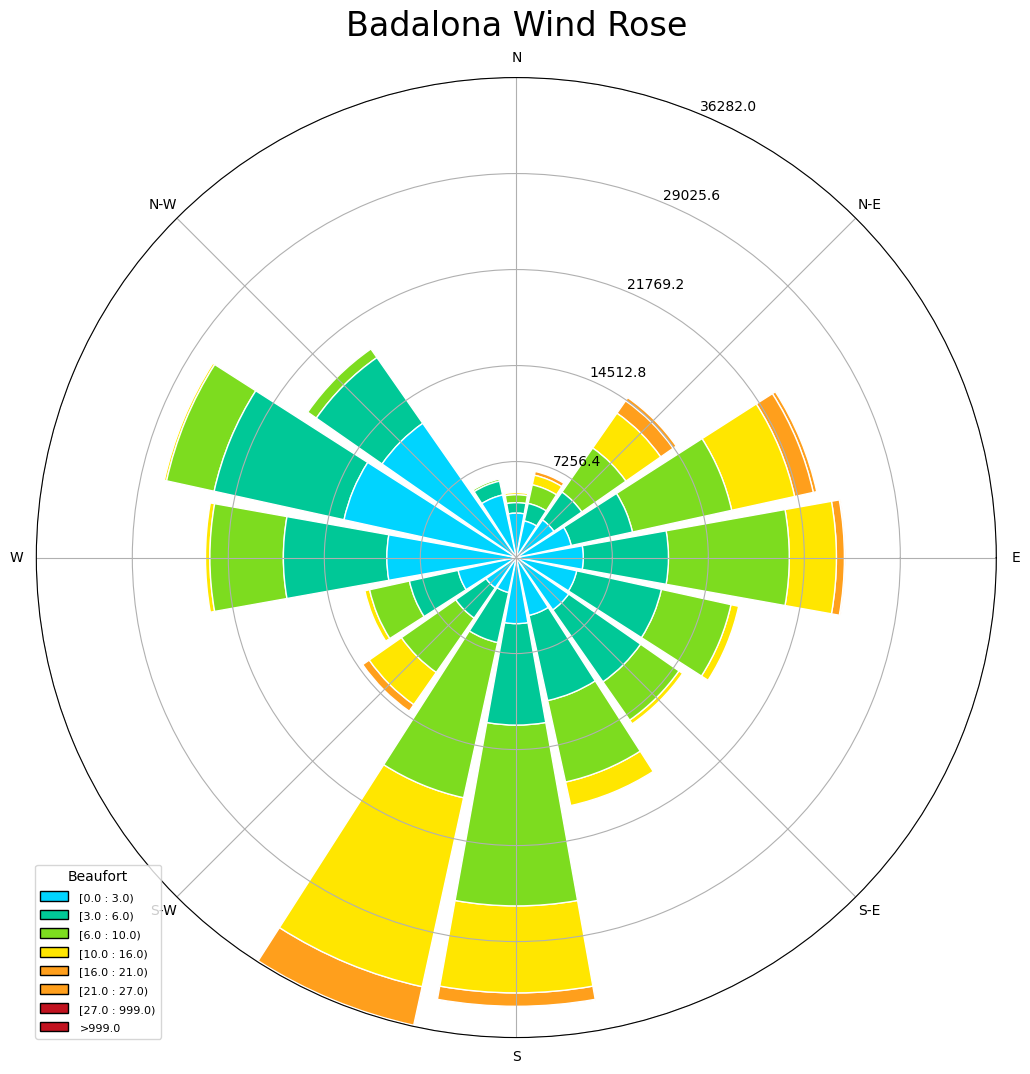

In [7]:
fig = plt.figure(
    figsize=(12,12)
)

ax = WindroseAxes.from_ax(
    fig=fig
)

ax.bar(
    df["wind_direction_deg"],
    df["wind_avg"],
    bins=beaufort_bins,
    opening=0.9,
    edgecolor="white",
    cmap=ListedColormap(colors)
)

ax.set_title(
    "Badalona Wind Rose",
    fontsize=24,
    pad=30
)

ax.set_legend(
    title="Beaufort"
)

plt.show()

In [8]:
total_hours = len(df) * 0.25

print(total_hours)

74668.5


In [9]:
ticks = ax.get_yticks()

hours = (
    ticks
    * total_hours
    / 100
)

ax.set_yticklabels(
    [f"{h:.0f} h" for h in hours]
)

[Text(0, 7256.4, '5418245 h'),
 Text(0, 14512.8, '10836490 h'),
 Text(0, 21769.199999999997, '16254735 h'),
 Text(0, 29025.6, '21672980 h'),
 Text(0, 36282.0, '27091225 h')]

In [10]:
ax.set_facecolor("#f5f5f5")

fig.patch.set_facecolor("white")

In [11]:
plt.savefig(
    "badalona_wind_rose.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>